In [2]:
import numpy as np
import pandas as pd

In [3]:
df = pd.read_csv("powerplant_data.csv")
df.head()

,AT,V,AP,RH,PE
0,8.34,40.77,1010.84,90.01,480.48
1,23.64,58.49,1011.40,74.20,445.75
2,29.74,56.90,1007.15,41.91,438.76
3,19.07,49.69,1007.22,76.79,453.09
4,11.80,40.66,1017.13,97.20,464.43


### AT => Temprature
### v => Vaccum
### AP => pressure
### RH => humidity

### PE => produce energy or Output

In [4]:
df.isnull().sum()

AT    0
V     0
AP    0
RH    0
PE    0
dtype: int64

In [5]:
X = df.drop(columns="PE")
y = df["PE"]

## Train Test Split

In [6]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state = 42
)

In [7]:
df.shape

(9568, 5)

In [8]:
from sklearn.preprocessing import StandardScaler
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.fit_transform(X_test)

In [9]:
import torch
import torch.nn as nn

X_train_tensor = torch.tensor(X_train_scaled, dtype=torch.float32)
y_train_tensor = torch.tensor(y_train.values, dtype=torch.float32).view(-1, 1)

X_test_tesnor = torch.tensor(X_test_scaled, dtype = torch.float32)
y_test_tensor = torch.tensor(y_test.values, dtype= torch.float32).view(-1,1)

In [10]:
print(type(X_train_scaled))
# It is an ndarray means on it we apply the standard scaler 
print(type(y_train))
# Here we are not apply the standard scaled it is simple pandas series for use that we apply the (.values)
print(y_train.shape)
# pytorch does not accept this shape(n,) for that we convert it into shape(n,1) 

<class 'numpy.ndarray'>
<class 'pandas.core.series.Series'>
(7654,)


### DataSet & DataLoader 

In [11]:
from torch.utils.data import TensorDataset, DataLoader
# Tensor DataSet
#   TensorDataset(in_feature, out_feature)
train_dataset = TensorDataset(X_train_tensor, y_train_tensor)
test_dataset = TensorDataset(X_test_tesnor, y_test_tensor)

In [12]:
# DataLoader
train_loader = DataLoader(train_dataset, batch_size = 32, shuffle=True)
test_loader = DataLoader(test_dataset, batch_size = 32, shuffle=True)
# shuffle = True for our data feed into shuffle format not the first 32 then next 32

## Deep Learning 

In [21]:
# Define our ANN Model
class ANN(nn.Module):
    def __init__(self):
        super(ANN,self ).__init__()

        self.model = nn.Sequential(
            # 1 Hidden Layer
            # nn.Linear(in_feature, out_feature)
            nn.Linear(X_train.shape[1],6),
            nn.ReLU(),
    
            # 2nd Hidden Layer
            nn.Linear(6,6),
            nn.ReLU(),
    
            # Output Layer
            nn.Linear(6,1) 
        )
    def forward(self, x):
        return self.model(x)

In [14]:
import torch.optim as optim

model = ANN()
# Loss, optimizer 
crietrion = nn.MSELoss() # using MSELoss we figure out that how our gradient descent curve looks (it is out LossFuction)
optimizer = optim.Adam(model.parameters( )) # we don't need to initialize weight and bias it is done by pytorch

In [15]:
# Training an ANN
train_losses = []
val_losses = []
epochs = 100
best_val_loss = float('inf')`
for epoch in range(epochs):
    model.train()
    running_loss = 0.0 # total training loss for 1 epoch 
    
    for xb, yb in train_loader:
        # xb => features of 1 batch
        # yb  => lables of 1 batch
        optimizer.zero_grad()  # for everytime gradient becomes zero for new batch gradient should be fresh
        outputs = model(xb) # forward prop... predicted output for this batch 
        loss = crietrion(outputs, yb) # compute loss
        loss.backward() # back prop... compute gradients
        optimizer.step() # params update
        running_loss += loss.item() # loss is a tensor value => convert it into pyton float
    epoch_train_loss = running_loss / len(train_loader)
    train_losses.append(epoch_train_loss)

    # Validation
    model.eval()
    running_val_loss = 0.0
    with torch.no_grad():
        for xb, yb in test_loader:
            outputs = model(xb) # forward prop... predicted output for this batch 
            loss = crietrion(outputs, yb) # compute loss
            running_val_loss += loss.item()
    epoch_val_loss = running_val_loss / len(test_loader)
    val_losses.append(epoch_val_loss) 

    print(f"epoch {epoch+1}/{epochs} ==> train loss == {epoch_train_loss}  & val loss {epoch_val_loss} ")

    if epoch_val_loss < best_val_loss:
        best_val_loss = epoch_val_loss
        torch.save(model.state_dict(),"Best _model.pt")  # store file into .pt or .pth

epoch 1/100 ==> train loss == 205282.6685546875  & val loss 202214.92838541666 
epoch 2/100 ==> train loss == 191573.58919270834  & val loss 175135.08671875 
epoch 3/100 ==> train loss == 148526.6044921875  & val loss 118221.28893229166 
epoch 4/100 ==> train loss == 87314.70598958334  & val loss 59437.462630208334 
epoch 5/100 ==> train loss == 41948.98798828125  & val loss 29706.73017578125 
epoch 6/100 ==> train loss == 24981.648221842446  & val loss 21451.492073567708 
epoch 7/100 ==> train loss == 19846.307495117188  & val loss 17709.740576171876 
epoch 8/100 ==> train loss == 16412.349879964193  & val loss 14428.707763671875 
epoch 9/100 ==> train loss == 13196.159431966145  & val loss 11263.311840820312 
epoch 10/100 ==> train loss == 10040.436771647135  & val loss 8276.614225260417 
epoch 11/100 ==> train loss == 7200.6615427653  & val loss 5659.770646158854 
epoch 12/100 ==> train loss == 4723.544967651367  & val loss 3480.762976074219 
epoch 13/100 ==> train loss == 2779.3095

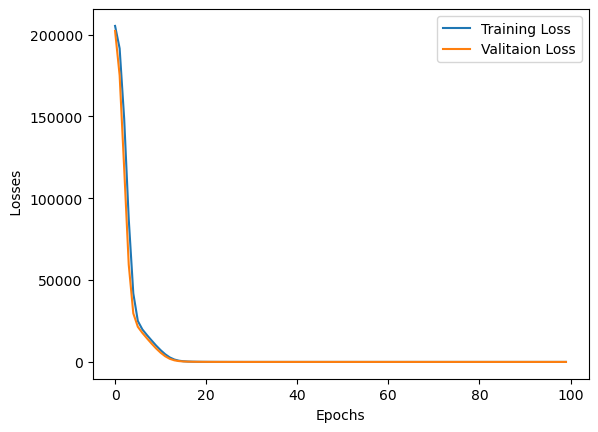

In [16]:
import matplotlib.pyplot as plt

loss_df = pd.DataFrame({
    "Training Loss" : train_losses,
    "Validation Loss" : val_losses 
})
plt.plot(loss_df["Training Loss"], label = "Training Loss")
plt.plot(loss_df["Validation Loss"], label = "Valitaion Loss")

plt.xlabel("Epochs")
plt.ylabel(" Losses")
plt.legend()

In [17]:
# Loading the best Model
model.load_state_dict(torch.load("Best _model.pt"))

<All keys matched successfully>

In [18]:
# Evaluation

model.eval()
with torch.no_grad():
    train_preds = model(X_train_tensor)
    test_preds = model(X_test_tesnor)

    train_mse_loss = crietrion(train_preds, y_train_tensor)
    test_mse_loss = crietrion(test_preds, y_test_tensor)

print(" Training MSE :-", train_mse_loss.item())
print(" Testing MSE :-", test_mse_loss.item())

 Training MSE :- 20.854990005493164
 Testing MSE :- 19.004085540771484


In [19]:
from sklearn.metrics import r2_score

print("r^2 score", r2_score(y_test, test_preds))

r^2 score 0.9335856285271656


In [20]:
Predicted_df = pd.DataFrame(test_preds.numpy(), columns=["Predicted Values"])
Actual_df = pd.DataFrame(y_test.values , columns=["Actual Values"])

pd.concat([Predicted_df, Actual_df], axis=1)

,Predicted Values,Actual Values
0,434.961853,433.27
1,436.494751,438.16
2,460.958282,458.42
3,475.813629,480.82
4,435.054962,441.41
...,...,...
1909,450.923737,456.70
1910,431.278229,438.04
1911,467.177765,467.80
1912,430.696564,437.14
